   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

--- KNN Performance with Different Distance Metrics (K=5) ---
Metric            Accuracy
---------------------------
euclidean          100.00%
manhattan          100.00%
chebyshev          100.00%
minkowski          100.00%

✅ Best Metric: euclidean with accuracy 100.00%

--- Classification Report (euclidean) ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy

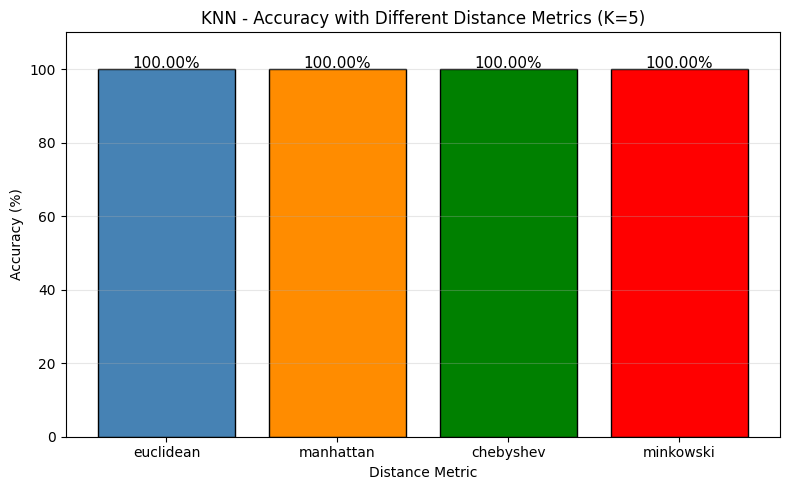

In [36]:
# ============================================================
#   K-NN CLASSIFIER - COMPARING DIFFERENT DISTANCE METRICS
#   Dataset: Iris
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset
df = pd.read_csv("Iris-ex-9,13.csv")
df.drop(columns=["Id"], inplace=True)
print(df.head())

# 2. Features & Target
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = df["Species"]

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (important for KNN!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 5. Distance Metrics to Compare
metrics = ["euclidean", "manhattan", "chebyshev", "minkowski"]
accuracies = []

print("\n--- KNN Performance with Different Distance Metrics (K=5) ---")
print(f"{'Metric':<15} {'Accuracy':>10}")
print("-" * 27)

for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{metric:<15} {acc * 100:>9.2f}%")

# 6. Best Metric
best_metric = metrics[accuracies.index(max(accuracies))]
print(f"\n✅ Best Metric: {best_metric} with accuracy {max(accuracies)*100:.2f}%")

# 7. Detailed Report for Best Metric
print(f"\n--- Classification Report ({best_metric}) ---")
knn_best = KNeighborsClassifier(n_neighbors=5, metric=best_metric)
knn_best.fit(X_train, y_train)
print(classification_report(y_test, knn_best.predict(X_test)))

# 8. Plot - Accuracy Comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, [a * 100 for a in accuracies],
               color=['steelblue', 'darkorange', 'green', 'red'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{acc*100:.2f}%", ha='center', fontsize=11)
plt.xlabel("Distance Metric")
plt.ylabel("Accuracy (%)")
plt.title("KNN - Accuracy with Different Distance Metrics (K=5)")
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 